# S2GOS Free Demo

Pick a site, a season and an instrument, and see what S2GOS produced for it.

**Nothing is simulated here.** Every result in this demo was rendered offline with S2GOS.

In [1]:
from s2gos_client.api import Client
client = Client(api_url="http://127.0.0.1:8008", auth_type="none")
app = client.show_app(height=700)

In [4]:
job_id = "job_0"
results = client.get_job_results(job_id)
results

JobResults(root={'dataset': {'B2': {'href': '/home/gonzalezm/test/test2/s2gos-mono/packages/s2gos-apps/example/precalculated_results/gobabeb/january/sim_output/pisa_sentinel2_s2-2.zarr'}, 'B3': {'href': '/home/gonzalezm/test/test2/s2gos-mono/packages/s2gos-apps/example/precalculated_results/gobabeb/january/sim_output/pisa_sentinel2_s2-3.zarr'}, 'B4': {'href': '/home/gonzalezm/test/test2/s2gos-mono/packages/s2gos-apps/example/precalculated_results/gobabeb/january/sim_output/pisa_sentinel2_s2-4.zarr'}, 'B8': {'href': '/home/gonzalezm/test/test2/s2gos-mono/packages/s2gos-apps/example/precalculated_results/gobabeb/january/sim_output/pisa_sentinel2_s2-8.zarr'}}, 'image': None, 'metadata': {'site': 'Gobabeb', 'season': 'December', 'instrument': 'msi', 'title': 'Gobabeb - Sentinel-2 MSI', 'acquired': '2024-12-21T13:00', 'sensor_id': 's2-4', 'created_at': '2026-07-30T11:04:57.951565', 'sza': 27.957724834079286, 'saa': 185.8935680884029, 'n_wavelengths': 10, 'wavelength_min_nm': 643.09346567411

In [5]:
from s2gos_utils.io.paths import PathRef, open_dataset
from s2gos_apps.processes.free_demo import true_color, plot_bands

/home/gonzalezm/test/test2/s2gos-mono/packages/s2gos-utils/src/s2gos_utils/io/paths.py:359: RuntimeWarning: 'netcdf4' fails while guessing
  engine = xr.backends.plugins.guess_engine(path.path)
/home/gonzalezm/test/test2/s2gos-mono/packages/s2gos-utils/src/s2gos_utils/io/paths.py:359: RuntimeWarning: 'scipy' fails while guessing
  engine = xr.backends.plugins.guess_engine(path.path)


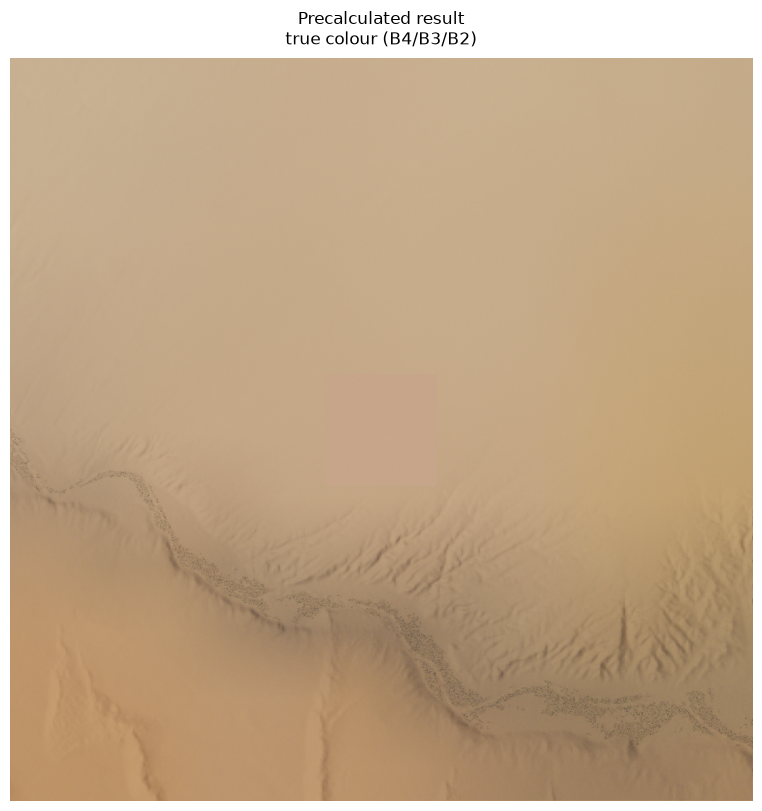

In [6]:
true_color(results.root["dataset"])

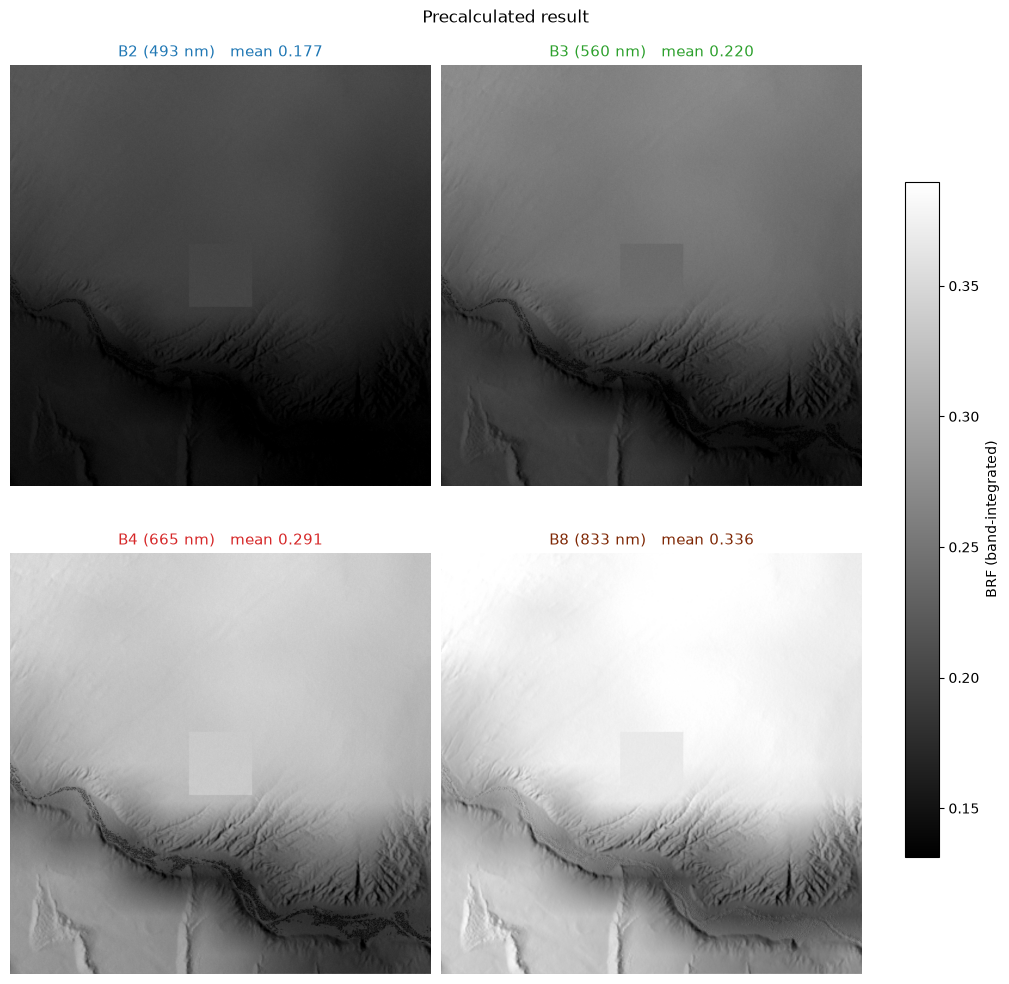

In [7]:
plot_bands(results.root["dataset"])

In [13]:
path_to_result = PathRef(**results.root['dataset']['B2'])
ds = open_dataset(path_to_result)
ds

/home/gonzalezm/test/test2/s2gos-mono/packages/s2gos-utils/src/s2gos_utils/io/paths.py:359: RuntimeWarning: 'netcdf4' fails while guessing
  engine = xr.backends.plugins.guess_engine(path.path)
/home/gonzalezm/test/test2/s2gos-mono/packages/s2gos-utils/src/s2gos_utils/io/paths.py:359: RuntimeWarning: 'scipy' fails while guessing
  engine = xr.backends.plugins.guess_engine(path.path)


<xarray.Dataset> Size: 928MB
Dimensions:         (w: 37, y_index: 1000, x_index: 1000, saa: 1, sza: 1)
Coordinates:
    bin_wmax        (w) float64 296B ...
    bin_wmin        (w) float64 296B ...
  * saa             (saa) float64 8B 185.9
  * sza             (sza) float64 8B 27.96
    vaa             (x_index, y_index) float64 8MB ...
    vza             (x_index, y_index) float64 8MB ...
  * w               (w) float64 296B 447.4 449.4 451.5 ... 527.7 530.5 533.3
    w_srf           float64 8B ...
    x               (x_index) float64 8kB ...
  * x_index         (x_index) int64 8kB 0 1 2 3 4 5 ... 994 995 996 997 998 999
    y               (y_index) float64 8kB ...
  * y_index         (y_index) int64 8kB 0 1 2 3 4 5 ... 994 995 996 997 998 999
Data variables:
    brdf            (w, y_index, x_index, saa, sza) float64 296MB ...
    brdf_srf        (y_index, x_index, saa, sza) float64 8MB ...
    brf             (w, y_index, x_index, saa, sza) float64 296MB ...
    brf_srf         (y_index, x_index, saa, sza) float64 8MB ...
    irradiance      (sza, saa, w) float64 296B ...
    irradiance_srf  (sza, saa) float64 8B ...
    radiance        (w, y_index, x_index, saa, sza) float64 296MB ...
    radiance_srf    (y_index, x_index, saa, sza) float64 8MB ...
Attributes:
    backend:            eradiate
    created_at:         2026-07-30T11:04:57.951565
    description:        None
    illumination_type:  directional
    measurement_types:  []
    num_measurements:   0
    num_sensors:        4
    output_dir:         gobabeb_sentinel2/sim_output
    result_type:        sensor
    sensor_id:          s2-2
    sensor_types:       ['satellite', 'satellite', 'satellite', 'satellite']
    simulation_name:    pisa_sentinel2

In [21]:
import matplotlib.pyplot as plt

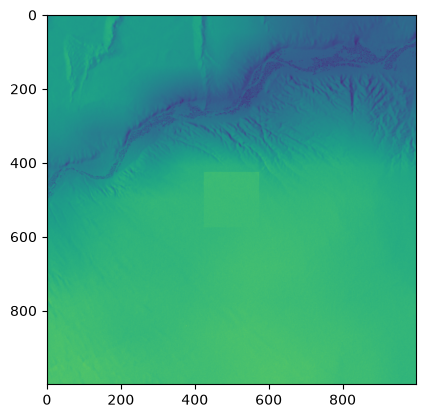

In [23]:
plt.imshow(ds.brf_srf.values.squeeze())